<a href="https://colab.research.google.com/github/AMIRMOHAMMAD-OSS/Phaseek/blob/main/phaseek_n3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🧪 Phaseek: Liquid–Liquid Phase Separation (LLPS) Protein Scorer

<img src="https://raw.githubusercontent.com/AMIRMOHAMMAD-OSS/Phaseek/main/Picture10.svg" alt="Phaseek Logo" width="800"/>

**Phaseek** is a high-throughput, efficient computational tool designed to predict the propensity of protein sequences to undergo **Liquid–Liquid Phase Separation (LLPS)**. It leverages a pre-trained model to assign an LLPS-propensity score to any given amino acid sequence, facilitating rapid screening and rational design in protein research.

---

## Key Features & Workflow

* **Protein Scoring**: Evaluate LLPS propensity for single sequences or batches at both **sequence** and **residue** levels.
* **Sequence Design**: Utilize Phaseek LLPS scores to generate *de novo* phase-separating peptides with **controllable** length and amino acid diversity.

---

## Citation

If you find Phaseek useful in your research, please cite our corresponding paper:

> **[Generalizable prediction of liquid-liquid phase separation from protein sequence]**(https://www.biorxiv.org/content/10.1101/2025.01.27.635039v1)

In [ ]:
#@title ⬇ 1. Installation and Environment Setup
#@markdown This cell installs all required dependencies and sets up the Phaseek repository. It may take a few minutes for the initial run.
%%capture
!pip install biopython streamlit py3Dmol requests biotite stmol command_runner plotly "kaleido==0.1.*" transformers ipympl
!apt-get update -qq && apt-get install -y ncbi-blast+
!pip install py3Dmol requests

# Clone/Setup Phaseek
import os
from google.colab import output

print("Starting environment setup...")
try:
    if not os.path.isdir("/content/Phaseek"):
        os.makedirs('/content/Phaseek/', exist_ok=True)
        !git clone https://github.com/AMIRMOHAMMAD-OSS/Phaseek /content/Phaseek/
        %cd /content/Phaseek/Functions
        output.clear()
        print("Environment setup complete! ✨")
    else:
        %cd /content/Phaseek/Functions
        output.clear()
        print("Phaseek is already installed and ready to use! ✅")
except Exception as e:
    print(f"Setup failed: {e}")

In [ ]:
#@title  2. Device Availability Check
#@markdown Confirms if a GPU is available, which significantly speeds up processing.
import torch

if torch.cuda.is_available():
    print("GPU is available! 🎉")
    print(f"Device: {torch.cuda.get_device_name(0)}")
    device = torch.device("cuda")
else:
    print("GPU is not available. Falling back to CPU. 😔")
    device = torch.device("cpu")

GPU is available! 🎉
Device: Tesla T4


In [20]:
#@title  3. Load and Score Protein Sequence(s)
#@markdown Enter a ***single sequence*** or the ***path to a FASTA file***.
Sequence = "MGKKQNRKTGNSKTQSASPPPKERSSSPATEQSWMENDFDELREEGFRRSNYSELREDIQTKGKEVENFEKNLEECITRITNTEKCLKELMELKTKARELREECRSLRSRCDQLEERVSAMEDEMNEMKREGKFREKRIKRNEQSLQEIWDYVKRPNLRLIGVPESDVENGTKLENTLQDIIQENFPNLARQANVQIQEIQRTPQRYSSRRATPRHIIVRFTKVEMKEKMLRAAREKGRVTLKGKPIRLTADLSAETLQARREWGPIFNILKEKNFQPRISYPAKLSFISEGEIKYFIDKQMLRDFVTTRPALKELLKEALNMERNNRYQPLQNHAKMLEHHHHHH" #@param {type:"string"}
Fasta_file = "" #@param {type:"string"}

#@markdown ---
#@markdown **Output Settings**
ID = "LINE1_ORF1" #@param {type:"string"}
Directory = "Human_LINE1" #@param {type:"string"}
End_sequence = 100
w = False
import os
import numpy as np
import ipywidgets as widgets
from IPython.display import display, clear_output
from command_runner import command_runner

def run_scoring(seq, seq_id):
    cmd = (
        f"python runner.py --sequence '{seq}' --end_sequence {End_sequence} "
        f"--plot True --directory '{Directory}' --id '{seq_id}'"
    )
    print(f"--- Scoring: {seq_id} ---")
    exit_code, output = command_runner(cmd, shell=True, live_output=True)
    return exit_code, output

def parse_fasta(path):
    sequences = []
    if os.path.exists(path):
        with open(path, 'r') as f:
            current_id = None
            current_seq = []
            for line in f:
                line = line.strip()
                if line.startswith(">"):
                    if current_id: sequences.append((current_id, "".join(current_seq)))
                    current_id = line[1:]
                    current_seq = []
                else:
                    current_seq.append(line)
            if current_id: sequences.append((current_id, "".join(current_seq)))
    return sequences

if os.path.exists(Fasta_file) and Fasta_file.lower().endswith(('.fasta', '.fa')):
    print(f"📂 FASTA file detected: {Fasta_file}")
    parsed_seqs = parse_fasta(Fasta_file)
    selector = widgets.SelectMultiple(
        options=[(s[0], i) for i, s in enumerate(parsed_seqs)],
        description='Sequences:',
        style={'description_width': 'initial'},
        layout=widgets.Layout(width='100%', height='200px')
    )

    select_all_btn = widgets.Button(description="Select All", button_style='info')
    run_btn = widgets.Button(description="Score Selected", button_style='success')
    output_area = widgets.Output()

    def on_select_all(_):
        selector.value = [i for i in range(len(parsed_seqs))]

    def on_run_clicked(_):
        with output_area:
            clear_output()
            if not selector.value:
                print("❌ Please select at least one sequence.")
                return
            for idx in selector.value:
                name, seq = parsed_seqs[idx]
                run_scoring(seq, name)

    select_all_btn.on_click(on_select_all)
    run_btn.on_click(on_run_clicked)

    display(widgets.VBox([
        widgets.HTML("<b>Select sequences from FASTA to score:</b>"),
        selector,
        widgets.HBox([select_all_btn, run_btn]),
        output_area
    ]))

else:
    # Single sequence execution
    w = True
    print("🧬 Scoring single sequence input...")
    out = run_scoring(Sequence, ID)
    score = float(out[1].split("Score")[1][2:-1])


🧬 Scoring single sequence input...
--- Scoring: LINE1_ORF1 ---
Score: 0.8204104346516234


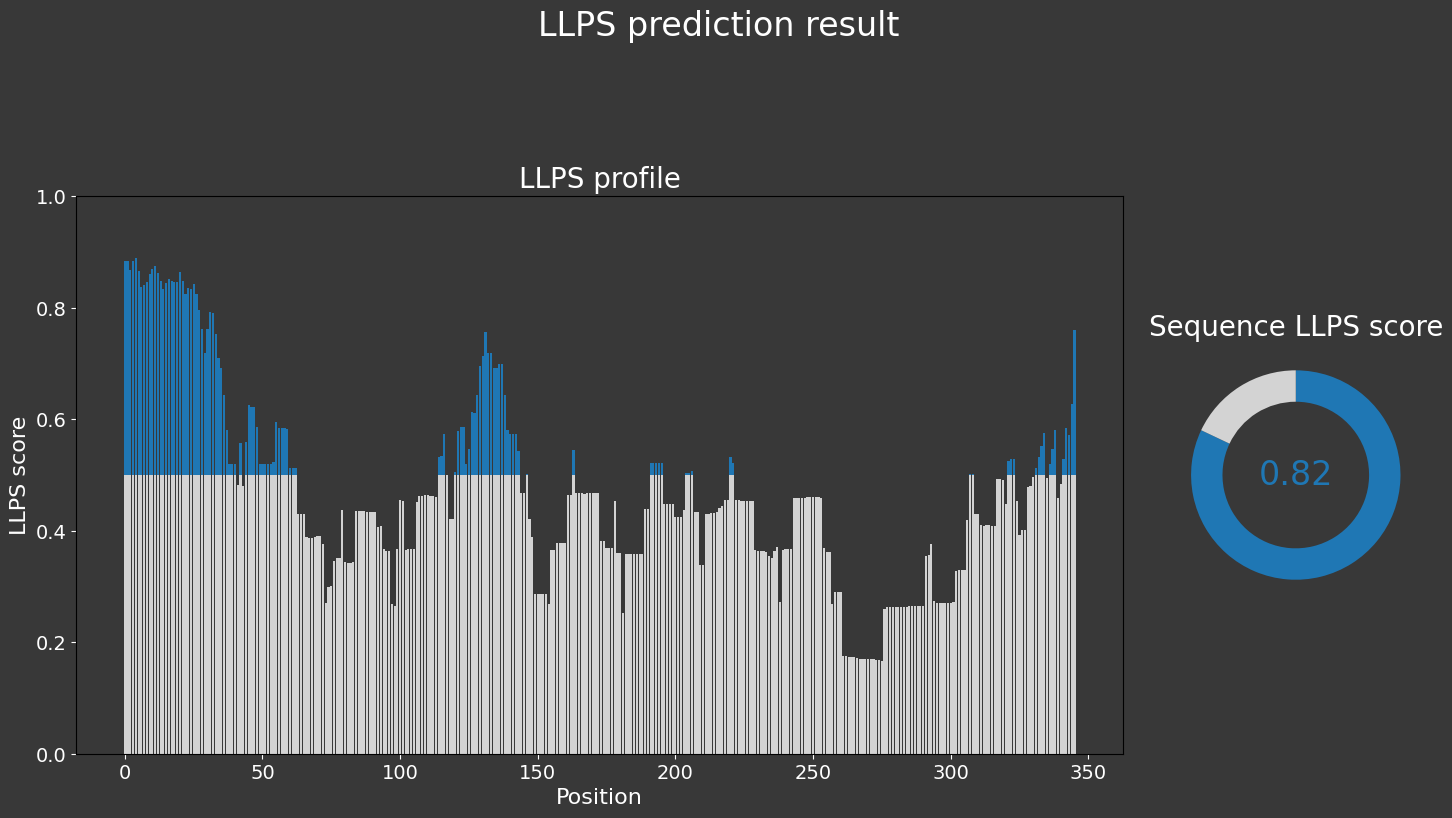

In [21]:
#@title plot
import matplotlib.pyplot as plt
import pandas as pd

if w:
    files = "/content/Phaseek/Results/{dir}/{id}/scores.csv".format(dir = Directory,id = ID)
    scores = pd.read_csv(files)["scores"].values.tolist()
    Sequence = "".join(pd.read_csv(files)["seq"].values.tolist())
    threshold = 0.5
    below_threshold = [min(k, threshold) for k in scores]
    above_threshold = [max(0, k - threshold) for k in scores]
    x_indices = list(range(len(scores)))

    metric_value = score
    main_color = "#1f77b4"
    background_color = "#383838"
    remaining_color = "#d3d3d3"

    fig, axes = plt.subplots(1, 2, figsize=(15, 8), gridspec_kw={'width_ratios': [4, 1]}, facecolor=background_color)

    fig.suptitle("LLPS prediction result", fontsize=24, color="white", y=1.05)
    ax1 = axes[0]
    ax1.bar(x_indices, below_threshold, color=remaining_color, label="Below Threshold")
    ax1.bar(x_indices, above_threshold, bottom=below_threshold, color=main_color, label="Above Threshold")
    ax1.set_ylim(0, 1)

    ax1.set_title("LLPS profile", color="white", fontsize=20)
    ax1.set_xlabel("Position", color="white", fontsize=16)
    ax1.set_ylabel("LLPS score", color="white", fontsize=16)
    ax1.tick_params(colors="white", labelsize=14)
    ax1.set_facecolor(background_color)
    ax2 = axes[1]
    ax2.pie(
        [metric_value, 1 - metric_value],
        colors=[main_color, remaining_color],
        startangle=90,
        counterclock=False,
        wedgeprops={'width': 0.3})

    ax2.text(0, 0, f'{metric_value:.2f}', ha='center', va='center', fontsize=24, color=main_color)
    ax2.set_aspect('equal')
    ax2.set_facecolor(background_color)
    ax2.axis('off')
    ax2.set_title("Sequence LLPS score", fontsize=20, color="white")

    plt.tight_layout(pad=3.0)
    plt.savefig("/content/Phaseek/Results/{dir}/{id}/LLPS_profile{iD}.svg".format(dir = Directory,id = ID,iD = ID), format='svg', bbox_inches='tight', facecolor=background_color)
    plt.show()


🚀 Predicting 3D structure for 346 residues via ESMFold...
✅ Structure saved to /content/Phaseek/Results/Human_LINE1/LINE1_ORF1/structure.pdb


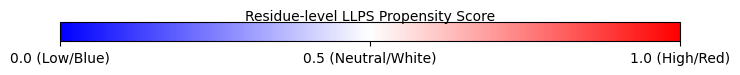

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [22]:
#@title 🧊 3D Structure Prediction & LLPS Mapping with Legend
#@markdown This cell uses ESMFold to predict the structure and colors it based on Phaseek residue scores.
#@markdown *Note: Sequence length is limited to 400 residues for speed.*

import requests
import py3Dmol
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.colorbar as mcolorbar # Explicitly import colorbar to avoid NameError
import numpy as np

MAX_LENGTH = 400 #@param {type:"integer"}

# --- 1. Helpler Function to Plot the Color Legend ---
def plot_colorbar_legend():
    """Plots a horizontal color bar to act as a legend for the 3D view."""
    fig, ax = plt.subplots(figsize=(8, 0.5))
    fig.subplots_adjust(bottom=0.5)

    cmap = plt.get_cmap('bwr') # Blue-White-Red gradient
    norm = mcolors.Normalize(vmin=0, vmax=1)

    # Use the explicitly imported mcolorbar
    cb1 = mcolorbar.ColorbarBase(ax, cmap=cmap,
                                norm=norm,
                                orientation='horizontal')

    # Adjust ticks and labels for clarity: Blue (0) -> White (0.5) -> Red (1)
    cb1.set_ticks([0.0, 0.5, 1.0])
    cb1.set_ticklabels(['0.0 (Low/Blue)', '0.5 (Neutral/White)', '1.0 (High/Red)'])
    cb1.set_label('Residue-level LLPS Propensity Score', labelpad=-40, y=1.5, fontsize=10)

    plt.show()

# --- 2. ESMFold Prediction Function ---
def predict_structure_esmfold(sequence):
    """Calls ESMFold API to get PDB data."""
    seq_to_fold = sequence
    if len(sequence) > MAX_LENGTH:
        print(f"⚠️ Sequence too long ({len(sequence)}). Truncating to {MAX_LENGTH} for folding...")
        seq_to_fold = sequence[:MAX_LENGTH]

    print(f"🚀 Predicting 3D structure for {len(seq_to_fold)} residues via ESMFold...")
    url = "https://api.esmatlas.com/foldSequence/v1/pdb/"
    response = requests.post(url, data=seq_to_fold)
    if response.status_code == 200:
        return response.text
    else:
        print(f"❌ Error connecting to ESMFold API: {response.status_code}")
        return None

# --- 3. Visualization Function ---
def visualize_llps_structure(pdb_str, scores):
    """Visualizes the PDB and colors residues by LLPS scores."""
    view = py3Dmol.view(width=800, height=600)
    view.addModel(pdb_str, "pdb")

    # Set default cartoon style
    view.setStyle({'model': -1}, {"cartoon": {'style': 'oval'}})

    norm = mcolors.Normalize(vmin=0, vmax=1)
    cmap = plt.get_cmap('bwr')

    # Color each RESIDUE based on score
    foldable_scores = scores[:MAX_LENGTH]
    for i, score in enumerate(foldable_scores):
        rgba = cmap(norm(score))
        hex_color = mcolors.to_hex(rgba)

        # Mapping score to residue index (resi)
        view.setStyle({'model': -1, 'resi': str(i + 1)},
                      {"cartoon": {'color': hex_color, 'style': 'oval'}})

    view.zoomTo()
    return view

# --- Execution Flow ---
if 'Sequence' in locals() and 'scores' in locals() and Sequence and scores:
    pdb_data = predict_structure_esmfold(Sequence)

    if pdb_data:
        try:
            # Ensure the directory exists before saving
            import os
            res_dir = f"/content/Phaseek/Results/{Directory}/{ID}/"
            os.makedirs(res_dir, exist_ok=True)

            pdb_path = os.path.join(res_dir, "structure.pdb")
            with open(pdb_path, "w") as f:
                f.write(pdb_data)
            print(f"✅ Structure saved to {pdb_path}")
        except Exception as e:
            print(f"⚠️ Could not save PDB file: {e}")

        # 1. Show the Gradient Legend
        plot_colorbar_legend()

        # 2. Show the 3D Model
        view = visualize_llps_structure(pdb_data, scores)
        view.show()
else:
     print("❌ Error: 'Sequence' or 'scores' not found. Please run the previous cells first.")

In [23]:
#@title Downloading the results

import shutil
import os
from google.colab import files

# Define the directory to be zipped
directory_to_zip = '/content/Phaseek/Results'

# Output zip file name
zip_file_name = '/content/Phaseek_analysis_results.zip'

# Create the ZIP file
shutil.make_archive(base_name=zip_file_name.replace('.zip', ''),
                    format='zip',
                    root_dir=directory_to_zip)

# Download the ZIP file
files.download(zip_file_name)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

---

# 🎯 Generating Phase-Separating Peptides with Phaseek

Phaseek offers two distinct optimization strategies for *de novo* design of sequences with high predicted LLPS propensity:

## Comparison of Design Methods

| Feature                  | **SeqProp (Gradient-Based)** | **AutoRegressive (Greedy/Stochastic)** |
|--------------------------|-------------------------------------------------------|-------------------------------------------------------|
| **Search Space** | Continuous (amino acid log-probability profiles)      | Discrete (explicit amino acid sequences)              |
| **Core Mechanism** | Backpropagation and Gradient Ascent                   | Stepwise, position-by-position residue selection      |
| **Benefits** | - Global exploration in a smooth landscape<br>- Typically achieves highest final LLPS score | - Fast and computationally efficient<br>- Guarantees valid, natural sequences quickly |
| **Drawbacks** | - Higher computational cost<br>- Requires careful tuning of hyperparameters | - Prone to **local optima** due to sequential, irreversible decisions |

---

## Controllable Parameters Overview

### **SeqProp Parameters**
* **GRADIENT_STEPS**: Number of optimization iterations. Higher = better score, slower runtime.
* **LEARNING_RATE**: Step size for gradient updates.
* **ENTROPY_WEIGHT**: Controls the trade-off between maximizing the score (exploitation) and exploring diverse sequences (exploration).
* **TEMP_START / TEMP_END**: Temperature annealing parameters for softmax, controlling exploration over time.
* **ENABLE_REFINEMENT**: Activates a final, local greedy search to polish the sequence.

### **AutoRegressive Parameters**
* **K_CHOICES**: The number of top-scoring residues sampled at each position. Set to 1 for a purely **Greedy** approach.
* **START_SEQUENCE**: A fixed N-terminal sequence prefix to start the design from.

**Guideline**: Use **SeqProp** for maximally optimized sequences; use **AutoRegressive** for speed and diverse initial candidates.

In [ ]:
#@title Phaseek: Design Execution & Control
#@markdown ---
#@markdown ### Design Method
DESIGN_METHOD = "SeqProp (Gradient-Based)" #@param ["SeqProp (Gradient-Based)", "AutoRegressive (Greedy/Stochastic)"]
DESIGN_MODE = "c" #@param ["a", "b", "c", "d", "e", "f", "g", "h"]
SEQUENCE_LENGTH = 120 #@param {type:"slider", min:20, max:512, step:10}
NUMBER_OF_SEQUENCES = 3 #@param {type:"slider", min:1, max:10, step:1}
RANDOM_SEED = 42 #@param {type:"number"}

#@markdown ---
#@markdown ### SeqProp Parameters
#@markdown *Only applied if SeqProp is selected.*
GRADIENT_STEPS = 500 #@param {type:"slider", min:100, max:1000, step:100}
LEARNING_RATE = 0.1 #@param {type:"number"}
ENTROPY_WEIGHT = 0.1 #@param {type:"number"}
TEMP_START = 2.0 #@param {type:"number"}
TEMP_END = 0.1 #@param {type:"number"}
ENABLE_REFINEMENT = False #@param {type:"boolean"}
LOG_EVERY_N_STEPS = 50 #@param {type:"number"}

#@markdown ---
#@markdown ### AutoRegressive Parameters
#@markdown *Only applied if AutoRegressive is selected.*
K_CHOICES = 3 #@param {type:"slider", min:1, max:10, step:1}
START_SEQUENCE = "M" #@param {type:"string"}

import numpy as np
import torch
import torch.nn.functional as F
import pandas as pd
import time
from tqdm.notebook import tqdm
from IPython.display import display, HTML

# --- CORE LOGIC (Setup & Global Functions) ---

try:
    from classifier_fgs import transformer
except ImportError:
    class DummyWrapper:
        def __init__(self, mode):
            d_emb = 128
            vocab_size = 30
            self._classifier = type('DummyClassifier', (), {
                'eval': lambda: None, 'parameters': lambda: [], 'to': lambda x: None,
                'transformer': type('DummyTransformer', (), {
                    'wte': type('DummyWTE', (), {'weight': torch.randn(vocab_size, d_emb)}),
                    'wpe': lambda x: torch.zeros(x.shape[0], x.shape[1], d_emb),
                    'drop': lambda x: x, 'h': [], 'ln_f': lambda x: x
                }),
                'ny': lambda x: x, 'classifier_head': lambda x: torch.randn(1, 2)
            })()
            self.vocab_dict = {a: i for i, a in enumerate("ACDEFGHIKLMNPQRSTVWY")}
        def predict_proba(self, seqs):
            scores = []
            for seq in seqs:
                charge_content = sum(seq.count(c) for c in 'RDEK') / len(seq) if len(seq) > 0 else 0
                score = 0.5 + 0.5 * np.tanh(charge_content * 5 - 2.5)
                scores.append([score, 1.0 - score])
            return np.array(scores)
    def transformer(mode): return DummyWrapper(mode)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
AA = "ACDEFGHIKLMNPQRSTVWY"
K = len(AA)
model = transformer(DESIGN_MODE)

def get_classifier_and_W_AA(mode: str = "c"):
    wrapper = transformer(mode)
    clf = wrapper._classifier
    clf.eval()
    for p in clf.parameters(): p.requires_grad = False
    vocab = wrapper.vocab_dict
    aa_token_ids = [vocab[a] for a in AA if a in vocab]
    W_AA = clf.transformer.wte.weight.detach()[aa_token_ids, :].to(device)
    clf.to(device)
    return wrapper, clf, W_AA

def scorerr(seq):
    valid_chars = set(AA)
    clean_seq = "".join(c.upper() for c in seq if c.upper() in valid_chars)
    if not clean_seq: return 0.0
    u = model.predict_proba([clean_seq])
    return float(u[0, 0]) if u.ndim == 2 else float(u[0])

# --- GENERATION WRAPPERS ---

def run_seqprop(**kwargs):
    length, steps, lr = kwargs['length'], kwargs['steps'], kwargs['lr']
    torch.manual_seed(kwargs['seed'])
    wrapper, clf, W_AA = get_classifier_and_W_AA(mode=kwargs['mode'])
    theta = torch.randn(length, K, device=device, requires_grad=True)
    optimizer = torch.optim.Adam([theta], lr=lr)

    for step in range(steps):
        temp = kwargs['temp_start'] + (kwargs['temp_end'] - kwargs['temp_start']) * (step / steps)
        optimizer.zero_grad(set_to_none=True)
        P_soft = F.softmax(theta / temp, dim=-1)
        E = P_soft @ W_AA
        x = E.unsqueeze(0)
        pos = torch.arange(0, x.size(1), dtype=torch.long, device=device).unsqueeze(0)
        x = clf.transformer.drop(x + clf.transformer.wpe(pos))
        for block in clf.transformer.h: x = block(x)
        logits = clf.ny(clf.classifier_head(clf.transformer.ln_f(x))).mean(1)
        score = torch.sigmoid(logits)[:, 0]
        loss = -score.mean() + (kwargs['entropy_weight'] * -(P_soft * torch.clamp(P_soft, min=1e-9).log()).sum(-1).mean())
        loss.backward()
        optimizer.step()

    with torch.no_grad():
        idxs = np.argmax(F.softmax(theta, dim=-1).cpu().numpy(), axis=1)
        final_seq = "".join(AA[i] for i in idxs)
    return final_seq, scorerr(final_seq)

def run_autoregressive_design(**kwargs):
    length, k_choices, p11 = kwargs['length'], kwargs['k_choices'], list(kwargs['start_seq'])
    np.random.seed(kwargs['seed'])
    for _ in tqdm(range(len(p11), length), desc="Designing", leave=False):
        current_seqs = ["".join(p11) + i for i in AA]
        scores = model.predict_proba(current_seqs)[:, 0]
        top_k_indices = np.argsort(scores)[-k_choices:]
        next_res = AA[np.random.choice(top_k_indices)]
        p11.append(next_res)
    res_seq = "".join(p11)
    return res_seq, scorerr(res_seq)

# --- EXECUTION ---

results = []
method_key = "SeqProp" if "SeqProp" in DESIGN_METHOD else "AutoRegressive"
start_time = time.time()

print(f"🧬 Starting {method_key} Design...")
for i in range(NUMBER_OF_SEQUENCES):
    current_seed = RANDOM_SEED + i
    if method_key == "SeqProp":
        s, sc = run_seqprop(length=SEQUENCE_LENGTH, steps=GRADIENT_STEPS, lr=LEARNING_RATE, entropy_weight=ENTROPY_WEIGHT,
                            mode=DESIGN_MODE, seed=current_seed, temp_start=TEMP_START, temp_end=TEMP_END)
    else:
        s, sc = run_autoregressive_design(length=SEQUENCE_LENGTH, k_choices=K_CHOICES, start_seq=START_SEQUENCE,
                                          mode=DESIGN_MODE, seed=current_seed)
    results.append({'ID': f'Phaseek_{i+1}', 'LLPS Score': round(sc, 5), 'Length': len(s), 'Sequence': s})

# --- STYLED OUTPUT ---

df = pd.DataFrame(results)
display(HTML(f"<h3>✅ Design Phase Complete ({time.time()-start_time:.2f}s)</h3>"))
display(df.style.background_gradient(subset=['LLPS Score'], cmap='viridis'))

🧬 Starting SeqProp Design...


,ID,LLPS Score,Length,Sequence
0,Phaseek_1,0.798210,120,QWAQTSTCRCRTRACKTCNKKKRKGTRQLVRMAWMTCHRTYTTWIHVLRKKRTVRRCYRRVCCWHRRRAVWGAVTRCTAVAAITRNNKVAARACFVATCLAWDSNRRFAQRAVARNRDRP
1,Phaseek_2,0.934180,120,TISSYGCYFFNTKHTFRVMKTNTTRRSQCVVFNVKTTNHGTHRTRIFQWFGHMYRRGRTRVVKQYRKKYVRGRGFARIMRKGADRAGCQNEAFVVERFKLNPIGHRHRYRVNHGGVYNDP
2,Phaseek_3,0.948370,120,ACGTVVCSCAAAVTCGIIYKGKVCIAHVYVFVYNCYKNRTTKGGRSVGPKIRVFCIVCVSVWLVYSIRVRFYSWWVLPYANTTFGANRFFNGVGFWVSPYRERCFLAMNLREGHAFRDDQ
